# Scientific context of the problem

High-energy physics, and more particularly the particle physics field, aims at establishing the elementary constituents of matter. This is usually achieved through protons and antiprotons collisions experiments in circular or linear accelerators to produce new, or "exotic" particles. The low ratio of creation of these new particles ($300$ for $10^{11}$ collisions in the case of the Higgs Boson for instance), and their quick decay into a different particle make their detection a very non-trivial task.

In this sense, and given the limited amount of data together with their expensive nature (both in terms of money and time), it is crucial to detect accurately true detections from noisy, background ones.

To this end, machine learning algorithms have been shown useful during the past decade and this notebook aims at developping and analysing some ML approaches to solve this binary (or two-class) classification problem.

**Reference**: this problem is based on [Baldi et al., Searching for exotic particles in high-energy physics with deep learning, Nature, 2014](https://www.nature.com/articles/ncomms5308).

This notebook is taken from Tony Bonnaire's [GitHub](https://github.com/tbonnair/Courses/tree/main/ENS_AI_Chemistry) (with minor variations)

# The data

In this problem, we consider a subset of the [SUSY](https://archive.ics.uci.edu/dataset/279/susy#) dataset (you don't need to download it). It consists in Monte-Carlo simulated data aiming at benchmarking algorithms to differentiate between collisions creating symmetric (exotic) particles and collisions creating standard model particles.

The data are arranged in 8 features representing kinematic properties measured by the accelerator sensors. Based on these features, the aim is to implement and compare several machine learning models.

# Prerequisites

Her we import the necessary packages, in particular, we will use:
> * [`matplotlib`](https://matplotlib.org/) for data visualisation and plots,
> * [`numpy`](https://numpy.org/) for standard numerical operations and algebra,
> * [`pandas`](https://pandas.pydata.org/) for data analysis,
> * [`scikit-learn`](https://scikit-learn.org/stable/) for ML algorithms and related functions used for model selection or data pre-processing.

In [7]:
import pandas                       # For data management
import matplotlib.pyplot as plt     # For plotting
import matplotlib as mpl            # For plotting setup
import numpy as np                  # For numerical calculations
import sklearn                      # Machine learning library
from sklearn import model_selection

# Formatting the plots
plt.rcParams['figure.figsize'] = [6,6]
plt.rcParams['font.size'] = 18
plt.rcParams['font.weight'] = 'normal'
plt.style.use('default')
mpl.rcParams['mathtext.fontset'] = 'cm'
mpl.rcParams['mathtext.rm'] = 'serif'
mpl.rcParams['font.size'] = 22
mpl.rcParams['axes.formatter.limits'] = (-6, 6)
mpl.rcParams['axes.formatter.use_mathtext'] = True
mpl.rcParams['font.family'] = 'STIXGeneral'
mpl.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
mpl.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
mpl.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
mpl.rcParams['xtick.minor.visible'] = True
mpl.rcParams['ytick.minor.visible'] = True

To download the subset of the SUSY dataset we'll use in this notebook, you can download it from [here](https://github.com/mlelarge/ens-ml4sd/releases/download/dataset/SUSY_subset_f1.csv.zip) The filename is `SUSY_subset_f1.csv.zip` that you'll have to unzip.

In [8]:
#!wget https://github.com/mlelarge/ens-ml4sd/releases/download/dataset/SUSY_subset_f1.csv.zip
#!unzip -q  'SUSY_subset_f1.csv.zip'

# Loading, exploring, and preparing the data

1. Load the data using the `pandas` library.

In [9]:
datapath = 'SUSY_subset_f1.csv'
dataset = pandas.read_csv(datapath)

2. Explore the data (how many events are there, what are the features, etc.) using the `pandas` library. What is the name of the key we want to predict? To access a given key (column), you can use `dataset['keyname']`.

In [10]:
dataset.head(5)

,isTrueDetection,lepton 1 pT,lepton 1 eta,lepton 1 phi,lepton 2 pT,lepton 2 eta,lepton 2 phi,missing energy magnitude,missing energy phi
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742


In [11]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   isTrueDetection            100000 non-null  float64
 1    lepton  1 pT              100000 non-null  float64
 2    lepton  1 eta             100000 non-null  float64
 3    lepton  1 phi             100000 non-null  float64
 4    lepton  2 pT              100000 non-null  float64
 5    lepton  2 eta             100000 non-null  float64
 6    lepton  2 phi             100000 non-null  float64
 7    missing energy magnitude  100000 non-null  float64
 8    missing energy phi        100000 non-null  float64
dtypes: float64(9)
memory usage: 6.9 MB


3. Check the proportion of events in the two classes.

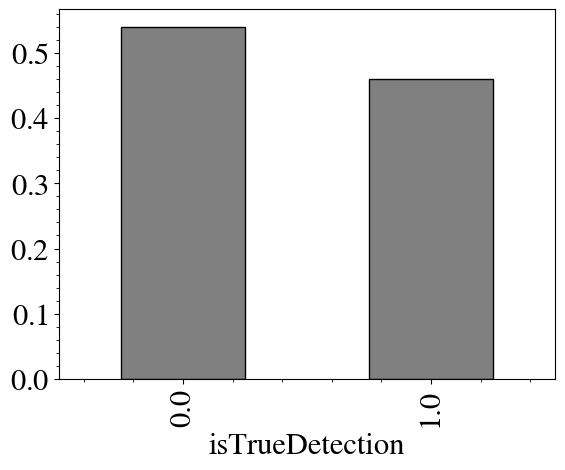

In [12]:
# Your code
dataset["isTrueDetection"].value_counts(normalize=True).plot.bar(fc='grey', ec='k')
plt.show()

4. Arrange the data into a feature matrix $\boldsymbol{X}$ and a target vector $\boldsymbol{y}$. Then, prepare the dataset and split it into 80% training and 20% test using the scikit-learn [`train_test_split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) function. **Remind the role of the train and test sets.**

In [13]:
# Your code
# First let's split the dataset into X and y (matrix and vector) as in the course
labels_features = dataset.keys()[1::]   # Labels of the feature in the dataset
label_pred = dataset.keys()[0]          # Label of the predicition

X = dataset[labels_features]
y = dataset[label_pred]

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=102)

print(len(X_train))
print(len(X_test))

80000
20000


# A first model: decision tree

Now the data are ready to be used for training, let us build a first model: a decision tree.

5. Using the scikit-learn documentation, find how to fit a Decision Tree with a maximum depth of 15 and using the entropy loss on the training dataset.

In [14]:
# Your code
from sklearn import tree

DT = tree.DecisionTreeClassifier(max_depth=15, criterion='entropy')
DT.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


6. Test your model on the test dataset and look at the obtained score.

In [16]:
# Your code
y_pred = DT.predict(X_test)
print(DT.score(X_test, y_test))

0.74825


In [17]:
DT.score(X_train, y_train)

0.8442375

7. Tune the hyperparameter of the maximum depth. To this end, split the training data again into two parts: a training dataset and a validation dataset. Then, find the hyperparameter having the best score on the validation set with depth in the range [1, 20].

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 19/19 [00:06<00:00,  2.84it/s]


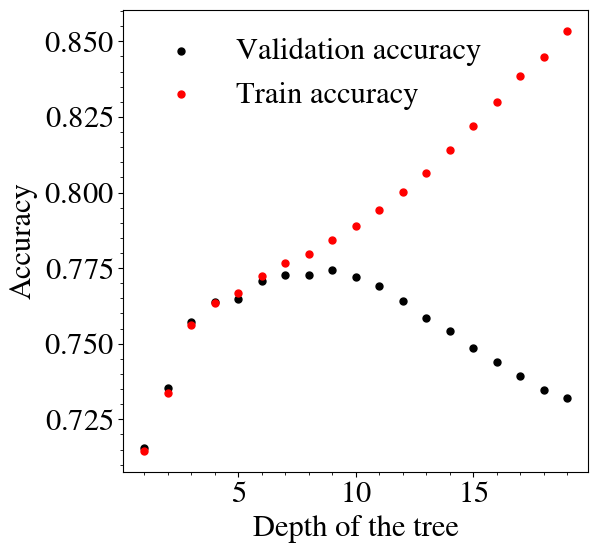

In [18]:
# Your code
from tqdm import tqdm   # To show loading bar

X_train2, X_valid, y_train2, y_valid = model_selection.train_test_split(X_train, y_train, test_size=0.3, random_state=102)

depths = np.arange(1, 20)

scores_validation = []
scores_training = []
for d in tqdm(depths):
  DT = tree.DecisionTreeClassifier(max_depth=d, criterion='entropy')
  DT.fit(X_train2, y_train2)
  scores_validation.append(DT.score(X_valid, y_valid))
  scores_training.append(DT.score(X_train, y_train))

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(depths, scores_validation, s=25, color='k', label=r'Validation accuracy')
ax.scatter(depths, scores_training, s=25, color='r', label=r'Train accuracy')
ax.set_xlabel(r'Depth of the tree')
ax.set_ylabel(r'Accuracy')
ax.legend(frameon=False)

8. Intepret the evolution of the validation score when varying the maximum depth: how does the validation error behaves and why? (To help you, you can also store and visualise the evolution of the training error in addition to validation error.)

Additional: You can also explore how your decision tree is classifying your data by using the [`plot_tree`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html) function from scikit-learn.

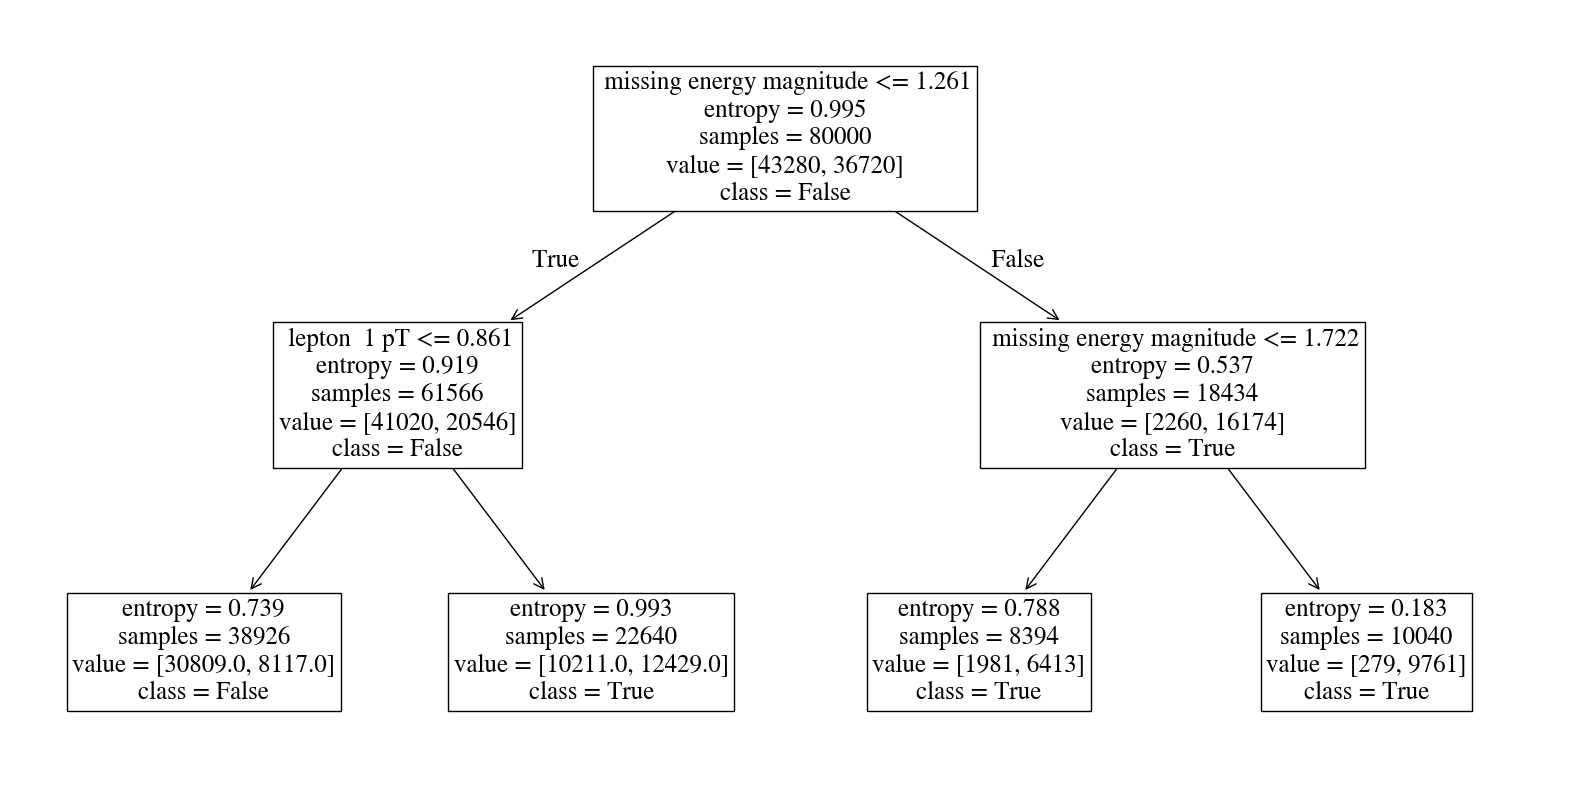

In [19]:
# Your code
DT = tree.DecisionTreeClassifier(max_depth=2, criterion='entropy')
DT.fit(X_train, y_train)

from sklearn.tree import plot_tree
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(DT, filled=False, feature_names=labels_features,
          class_names=['False', 'True'], ax=ax, fontsize=18,
)
plt.show()

# Improving the model with more trees: random forest

9. Using the scikit-learn documentation, fit a random forest to the training data with a number of trees of 20 and a maximum depth of 15. Compare this setup with our first decision tree.

In [20]:
# Your code
from sklearn.ensemble import RandomForestClassifier

RF = RandomForestClassifier(n_estimators=20, max_depth=15, criterion='entropy')

RF.fit(X_train, y_train)

print(RF.score(X_test, y_test))

0.77905


10. Repeat the hyperparameter tuning for tuning the number of trees in [1, 50] at fixed maximum depth = 15 to find the best random forest model for our data.

In [21]:
# Your code
from tqdm import tqdm   # To show loading bar

ntrees = [1, 2, 4, 8, 10, 15, 20, 25, 30, 35, 40, 50]
print(ntrees)

scores_generalization_RF = []
scores_training_RF = []
for n in tqdm(ntrees):
  RF_valid = RandomForestClassifier(n_estimators=n, max_depth=15, criterion='entropy')
  RF_valid.fit(X_train2, y_train2)
  scores_generalization_RF.append(RF_valid.score(X_valid, y_valid))
  scores_training_RF.append(RF_valid.score(X_train, y_train))

[1, 2, 4, 8, 10, 15, 20, 25, 30, 35, 40, 50]


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 12/12 [00:23<00:00,  1.95s/it]


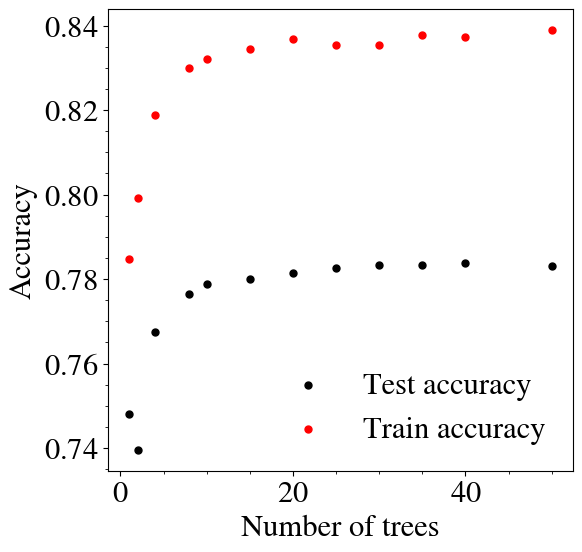

In [22]:
# Plot
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(ntrees, scores_generalization_RF, s=25, color='k', label=r'Test accuracy')
ax.scatter(ntrees, scores_training_RF, s=25, color='r', label=r'Train accuracy')
ax.set_xlabel(r'Number of trees')
ax.set_ylabel(r'Accuracy')
ax.legend(frameon=False)

11. Does the curve showing the evolution of the test error look the same as previously with the decision tree depth? Why?

Bonus: What other tree-based method could you use to solve this classification task? Check it out on scikit-learn.

# Importance of hand-crafted features

For such models that do not learn new features from the data, hand-crafted can matter a lot for the performance.
This is in fact what the authors releasing the SUSY dataset did by providing additionally 10 hand-crafted features that are functions of the eight first obtained directly from the sensors.

Download the new dataset [here](https://github.com/mlelarge/ens-ml4sd/releases/download/dataset/SUSY_subset2_all_features.csv.zip) and explore the new data as before.


In [23]:
#!wget https://github.com/mlelarge/ens-ml4sd/releases/download/dataset/SUSY_subset2_all_features.csv.zip
#!unzip -q  'SUSY_subset2_all_features.csv.zip'
datapath2 = 'SUSY_subset2_all_features.csv'
dataset2 = pandas.read_csv(datapath2)

In [24]:
print(dataset2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   0       100000 non-null  float64
 1   1       100000 non-null  float64
 2   2       100000 non-null  float64
 3   3       100000 non-null  float64
 4   4       100000 non-null  float64
 5   5       100000 non-null  float64
 6   6       100000 non-null  float64
 7   7       100000 non-null  float64
 8   8       100000 non-null  float64
 9   9       100000 non-null  float64
 10  10      100000 non-null  float64
 11  11      100000 non-null  float64
 12  12      100000 non-null  float64
 13  13      100000 non-null  float64
 14  14      100000 non-null  float64
 15  15      100000 non-null  float64
 16  16      100000 non-null  float64
 17  17      100000 non-null  float64
 18  18      100000 non-null  float64
dtypes: float64(19)
memory usage: 14.5 MB
None


12. Fit a random forest on the full set of features and compare the obtained results with the previous features.

In [29]:
# @title
from sklearn.ensemble import RandomForestClassifier

labels_features = dataset2.keys()[1::]   # Labels of the feature in the dataset
label_pred = dataset2.keys()[0]          # Label of the predicition

X2 = dataset2[labels_features]
y2 = dataset2[label_pred]

X2_train, X2_test, y2_train, y2_test = model_selection.train_test_split(X2, y2, test_size=0.2, random_state=102)
RF = RandomForestClassifier(n_estimators=30, max_depth=15, criterion='entropy')

RF.fit(X2_train, y2_train)

print(RF.score(X2_test, y2_test))

0.791


## Cross-validation and Randomized search for hyperparameter tuning
In our examples, we always focus on one hyperparameter at a time, and using a validation set. In fact, using scikit-learn you can specify several ranges for your hyperparameters and test them randomly to find the association of parameters using randomized search or grid search cross-validation. Randomized search is more efficient numerically but is not leading you to the best possible set of parameters, while grid search consists in an exhaustive search in your pre-defined ranges for parameters. Here we illustrate it with randomized search.

In [18]:
from sklearn.model_selection import RandomizedSearchCV

# define range of values for each hyperparameter
hyperparameters_range = [{
        "n_estimators": [1, 5, 10, 20, 40],       # Number of trees
        "max_features": [0.5, 1.0, "sqrt", "log2"],  # Proportion of the features used for training you RFs
        "max_depth": [5, 10, 15, 20],  # Maximum depth of the trees trained in RFs
    }]

# Create a base model
RF = RandomForestClassifier(n_estimators=20, max_depth=15, n_jobs=-1)

# Random search with cross validation
RF_CV = RandomizedSearchCV(
    RF, param_distributions=hyperparameters_range, cv=5)

# Fit the search
RF_CV.fit(X_train, y_train)

,estimator,"RandomForestC...20, n_jobs=-1)"
,param_distributions,"[{'max_depth': [5, 10, ...], 'max_features': [0.5, 1.0, ...], 'n_estimators': [1, 5, ...]}]"
,n_iter,10
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


You can now select the best model and test it.

In [19]:
print(RF_CV.best_params_)         # Prints the best parameters
RF_best = RF_CV.best_estimator_   # Select the best model
RF_best.score(X_test, y_test)     # Test dataset

{'n_estimators': 40, 'max_features': 'sqrt', 'max_depth': 10}


0.78135

You could do similarly with the [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) function from scikit-learn to perform grid search cross-validation for tuning your hyperparameters.